# Adaptive Cyber-Physical Security: Baseline Anomaly Detection
## Project 2 — Phase 1: Baseline ML Models

**Objective:** Build and evaluate baseline anomaly detection models for network intrusion detection using simple statistical thresholding and distance-based methods, trained exclusively on normal (benign) traffic.

**Dataset:** NSL-KDD — A refined benchmark for network intrusion detection systems.

---

## 1. Literature Review & Theoretical Foundation

### 1.1 Background: Anomaly-Based Intrusion Detection

Traditional intrusion detection systems (IDS) rely on **signature matching** — comparing network packets against a database of known attack patterns (Roesch, 1999). While effective for known threats, they fundamentally cannot detect **zero-day attacks** or novel attack variants. This motivates **anomaly-based detection**, which learns a model of "normal" behavior and flags deviations (Chandola et al., 2009).

### 1.2 Prior Work & Baseline Methods

| Method | Category | Reference | Key Idea |
|--------|----------|-----------|----------|
| Statistical Thresholding (Z-Score) | Statistical | Denning (1987) | Flag observations whose feature values deviate beyond *k* standard deviations from the learned normal profile |
| Isolation Forest | Tree-based | Liu et al. (2008) | Anomalies are "few and different" — they require fewer random splits to isolate |
| One-Class SVM | Kernel-based | Schölkopf et al. (2001) | Learn a decision boundary around normal data in kernel space |
| Autoencoders | Deep Learning | Sakurada & Yairi (2014) | Learn compressed representations; anomalies yield high reconstruction error |

### 1.3 Why These Baselines?

We select **Z-Score thresholding** and **Isolation Forest** as baselines because:
- **Z-Score** represents the simplest statistical approach — it establishes a performance floor with minimal assumptions (only requires Gaussian-like feature behavior).
- **Isolation Forest** is the standard tree-based anomaly detector — it handles mixed feature distributions and is robust to the curse of dimensionality (Liu et al., 2008).
- Both are **unsupervised/semi-supervised**: they train on normal data only, matching the project's emphasis on detecting *unknown* threats.
- They serve as interpretable benchmarks against which advanced models (autoencoders, sequence models) can be compared.

### 1.4 The NSL-KDD Dataset

The NSL-KDD dataset (Tavallaee et al., 2009) addresses key limitations of the original KDD Cup '99 dataset:
- **No duplicate records** → classifiers aren't biased toward frequent patterns
- **Balanced difficulty** → test set includes records of varying difficulty levels
- **41 features** covering TCP connection attributes, content features, and traffic statistics
- **Attack categories**: DoS, Probe, R2L (Remote-to-Local), U2R (User-to-Root)

**Key assumption**: We treat all attack types as a single "anomaly" class, framing the problem as binary anomaly detection (normal vs. anomaly).

### 1.5 References

1. Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection: A survey. *ACM Computing Surveys*, 41(3), 1–58.
2. Denning, D. E. (1987). An intrusion-detection model. *IEEE Transactions on Software Engineering*, SE-13(2), 222–232.
3. Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation forest. *ICDM*, 413–422.
4. Roesch, M. (1999). Snort — Lightweight intrusion detection for networks. *LISA*, 229–238.
5. Sakurada, M., & Yairi, T. (2014). Anomaly detection using autoencoders with nonlinear dimensionality reduction. *MLSDA Workshop*.
6. Schölkopf, B., Platt, J. C., et al. (2001). Estimating the support of a high-dimensional distribution. *Neural Computation*, 13(7), 1443–1471.
7. Tavallaee, M., Bagheri, E., Lu, W., & Ghorbani, A. A. (2009). A detailed analysis of the KDD CUP 99 data set. *IEEE CISDA*.

---

## 2. Environment Setup & Data Loading

In [1]:
# ============================================================
# 2.1 Import Libraries
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from urllib.request import urlretrieve

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'figure.dpi': 100
})
sns.set_style("whitegrid")
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# 2.2 Download NSL-KDD Dataset
# ============================================================
import subprocess

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs('./results', exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/"
FILES = {
    'train': 'KDDTrain+.txt',
    'test': 'KDDTest+.txt'
}

for key, fname in FILES.items():
    filepath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(filepath):
        print(f"Downloading {fname}...")
        subprocess.run(['curl', '-sL', '-o', filepath, BASE_URL + fname], check=True)
        print(f"  Saved to {filepath}")
    else:
        print(f"  {fname} already exists.")

print("\nDataset download complete.")

  KDDTrain+.txt already exists.
  KDDTest+.txt already exists.

Dataset download complete.


In [3]:
# ============================================================
# 2.3 Load Data with Column Names
# ============================================================
# NSL-KDD column names (41 features + label + difficulty_level)
COLUMN_NAMES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

df_train = pd.read_csv(os.path.join(DATA_DIR, 'KDDTrain+.txt'), header=None, names=COLUMN_NAMES)
df_test = pd.read_csv(os.path.join(DATA_DIR, 'KDDTest+.txt'), header=None, names=COLUMN_NAMES)

print(f"Training set shape: {df_train.shape}")
print(f"Test set shape:     {df_test.shape}")
print(f"\nTraining columns ({len(COLUMN_NAMES)}): {COLUMN_NAMES[:5]} ... {COLUMN_NAMES[-3:]}")
df_train.head()

Training set shape: (125973, 43)
Test set shape:     (22544, 43)

Training columns (43): ['duration', 'protocol_type', 'service', 'flag', 'src_bytes'] ... ['dst_host_srv_rerror_rate', 'label', 'difficulty_level']


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Exploratory Data Analysis (EDA)

> **Goal:** Understand the dataset's structure, distributions, and characteristics to make *informed* preprocessing and modeling decisions. Every visualization below directly influences a downstream design choice.

---

In [4]:
# ============================================================
# 3.1 Dataset Overview — Structure, Types, Missing Values
# ============================================================
print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"\nTraining samples:  {len(df_train):,}")
print(f"Test samples:      {len(df_test):,}")
print(f"Total features:    {df_train.shape[1] - 2} (excluding label & difficulty_level)")

# Data types
print(f"\n--- Data Types ---")
print(f"Numerical features:   {df_train.select_dtypes(include=[np.number]).shape[1] - 1}")  # exclude difficulty
print(f"Categorical features: {df_train.select_dtypes(include=['object']).shape[1] - 1}")  # exclude label

# Missing values
missing = df_train.isnull().sum()
print(f"\n--- Missing Values ---")
if missing.sum() == 0:
    print("No missing values found in training data.")
else:
    print(missing[missing > 0])

# Duplicate check
dup_count = df_train.duplicated().sum()
print(f"\n--- Duplicates ---")
print(f"Duplicate rows in training set: {dup_count} ({100*dup_count/len(df_train):.2f}%)")
print("(NSL-KDD was specifically designed to remove duplicates from KDD'99)")

DATASET STRUCTURE

Training samples:  125,973
Test samples:      22,544
Total features:    41 (excluding label & difficulty_level)

--- Data Types ---
Numerical features:   38
Categorical features: 3

--- Missing Values ---
No missing values found in training data.

--- Duplicates ---
Duplicate rows in training set: 0 (0.00%)
(NSL-KDD was specifically designed to remove duplicates from KDD'99)


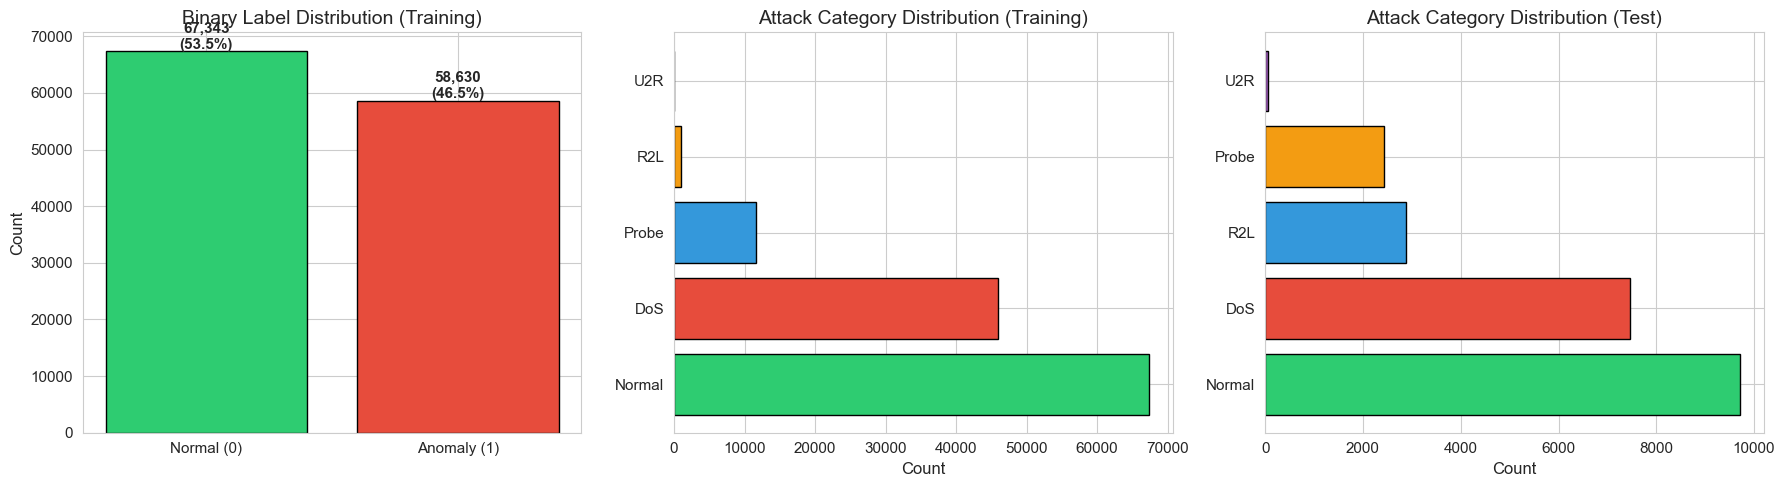


Training: Normal=67,343 (53.5%), Anomaly=58,630 (46.5%)

Key Observation: The dataset is roughly balanced between normal and attack traffic.
However, for our semi-supervised setup, we train ONLY on normal data.


In [5]:
# ============================================================
# 3.2 Label Distribution — Understanding Class Imbalance
# ============================================================
# Map specific attack labels to categories
ATTACK_MAPPING = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'snmpgetattack': 'R2L', 'named': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L',
    'sendmail': 'R2L', 'httptunnel': 'R2L', 'worm': 'R2L', 'snmpguess': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'xterm': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
}

df_train['attack_cat'] = df_train['label'].map(ATTACK_MAPPING).fillna('Unknown')
df_test['attack_cat'] = df_test['label'].map(ATTACK_MAPPING).fillna('Unknown')

# Binary label: 0 = Normal, 1 = Anomaly
df_train['binary_label'] = (df_train['label'] != 'normal').astype(int)
df_test['binary_label'] = (df_test['label'] != 'normal').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Binary distribution
binary_counts = df_train['binary_label'].value_counts()
axes[0].bar(['Normal (0)', 'Anomaly (1)'], binary_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Binary Label Distribution (Training)')
axes[0].set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({100*v/len(df_train):.1f}%)', ha='center', fontweight='bold')

# (b) Attack category distribution
cat_counts = df_train['attack_cat'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#95a5a6']
axes[1].barh(cat_counts.index, cat_counts.values, color=colors[:len(cat_counts)], edgecolor='black')
axes[1].set_title('Attack Category Distribution (Training)')
axes[1].set_xlabel('Count')

# (c) Test set distribution (to compare)
test_cat_counts = df_test['attack_cat'].value_counts()
axes[2].barh(test_cat_counts.index, test_cat_counts.values, color=colors[:len(test_cat_counts)], edgecolor='black')
axes[2].set_title('Attack Category Distribution (Test)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('./results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining: Normal={binary_counts[0]:,} ({100*binary_counts[0]/len(df_train):.1f}%), "
      f"Anomaly={binary_counts[1]:,} ({100*binary_counts[1]/len(df_train):.1f}%)")
print(f"\nKey Observation: The dataset is roughly balanced between normal and attack traffic.")
print("However, for our semi-supervised setup, we train ONLY on normal data.")

In [6]:
# ============================================================
# 3.3 Feature Distribution Analysis — Identifying Skewness & Outliers
# ============================================================
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.drop(['binary_label', 'difficulty_level'])

# Statistical summary
stats = df_train[numerical_cols].describe().T
stats['skewness'] = df_train[numerical_cols].skew()
stats['kurtosis'] = df_train[numerical_cols].kurtosis()
stats['iqr'] = stats['75%'] - stats['25%']

print("=" * 60)
print("FEATURE STATISTICS — Key Observations")
print("=" * 60)

# Identify highly skewed features
highly_skewed = stats[stats['skewness'].abs() > 5].index.tolist()
print(f"\nHighly skewed features (|skewness| > 5): {len(highly_skewed)}")
for f in highly_skewed[:8]:
    print(f"  {f:35s} skewness={stats.loc[f,'skewness']:>10.2f}  range=[{stats.loc[f,'min']:.0f}, {stats.loc[f,'max']:.0f}]")

# Identify zero-variance features
zero_var = stats[stats['std'] == 0].index.tolist()
print(f"\nZero-variance features: {zero_var}")
print("  → These carry no information and will be dropped during preprocessing.")

# Display top features by variance
print(f"\nTop 10 features by standard deviation:")
print(stats.nlargest(10, 'std')[['mean', 'std', 'min', 'max', 'skewness']].to_string())

FEATURE STATISTICS — Key Observations

Highly skewed features (|skewness| > 5): 18
  duration                            skewness=     11.88  range=[0, 42908]
  src_bytes                           skewness=    190.67  range=[0, 1379963888]
  dst_bytes                           skewness=    290.05  range=[0, 1309937401]
  land                                skewness=     70.97  range=[0, 1]
  wrong_fragment                      skewness=     11.46  range=[0, 3]
  urgent                              skewness=    149.91  range=[0, 3]
  hot                                 skewness=     12.59  range=[0, 77]
  num_failed_logins                   skewness=     53.76  range=[0, 5]

Zero-variance features: ['num_outbound_cmds']
  → These carry no information and will be dropped during preprocessing.

Top 10 features by standard deviation:
                            mean           std  min           max    skewness
src_bytes           45566.743000  5.870331e+06  0.0  1.379964e+09  190.669347
ds

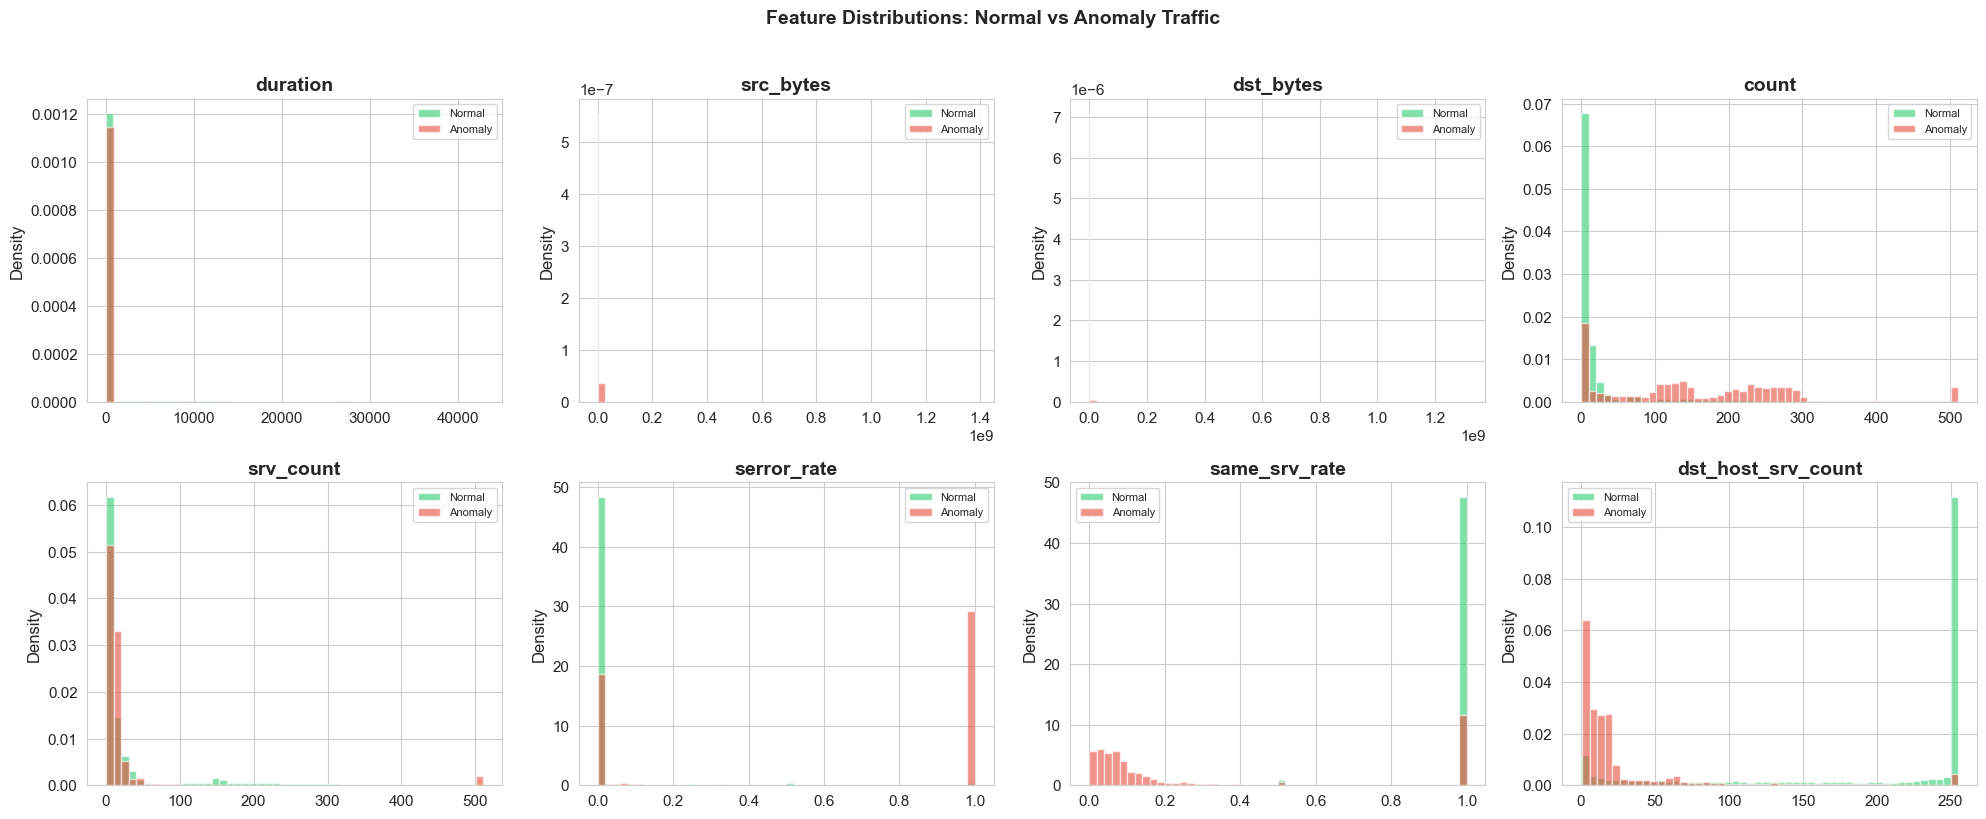

Observation: Many features exhibit heavy-tailed distributions (e.g., src_bytes, dst_bytes).
This means Z-Score thresholding may flag tails as anomalies → we need careful threshold tuning.
Rate-based features (serror_rate, same_srv_rate) show clear separation between classes → strong signals.


In [7]:
# ============================================================
# 3.4 Distribution Visualization — Heavy Tails & Multi-modality
# ============================================================
# Select representative features across different scales
plot_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
                 'serror_rate', 'same_srv_rate', 'dst_host_srv_count']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    normal_data = df_train[df_train['binary_label'] == 0][feat]
    attack_data = df_train[df_train['binary_label'] == 1][feat]

    axes[i].hist(normal_data, bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
    axes[i].hist(attack_data, bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Normal vs Anomaly Traffic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: Many features exhibit heavy-tailed distributions (e.g., src_bytes, dst_bytes).")
print("This means Z-Score thresholding may flag tails as anomalies → we need careful threshold tuning.")
print("Rate-based features (serror_rate, same_srv_rate) show clear separation between classes → strong signals.")

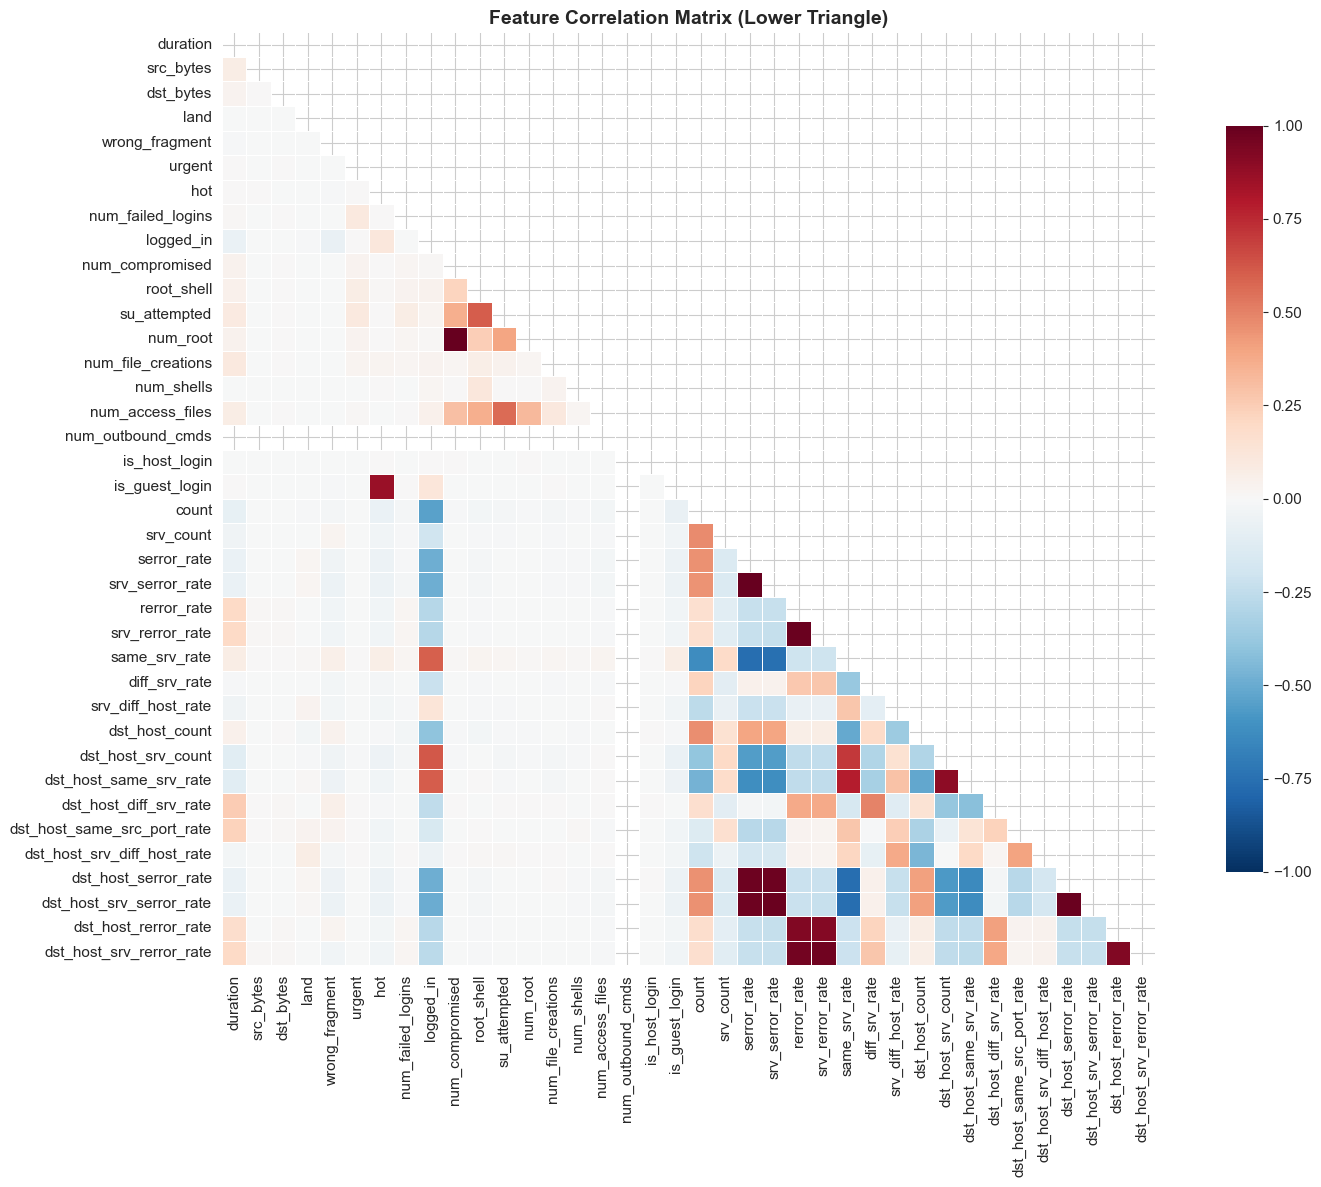


Highly correlated feature pairs (|r| > 0.9): 13
  num_compromised                     ↔ num_root                             r=0.999
  serror_rate                         ↔ srv_serror_rate                      r=0.993
  serror_rate                         ↔ dst_host_serror_rate                 r=0.979
  serror_rate                         ↔ dst_host_srv_serror_rate             r=0.981
  srv_serror_rate                     ↔ dst_host_serror_rate                 r=0.978
  srv_serror_rate                     ↔ dst_host_srv_serror_rate             r=0.986
  rerror_rate                         ↔ srv_rerror_rate                      r=0.989
  rerror_rate                         ↔ dst_host_rerror_rate                 r=0.927
  rerror_rate                         ↔ dst_host_srv_rerror_rate             r=0.964
  srv_rerror_rate                     ↔ dst_host_rerror_rate                 r=0.918

Implication: High multicollinearity suggests some features are redundant.
We retain all for the base

In [8]:
# ============================================================
# 3.5 Correlation Analysis — Feature Redundancy & Multicollinearity
# ============================================================
# Compute correlation on numerical features
corr_matrix = df_train[numerical_cols].corr()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                    corr_matrix.iloc[i, j]))

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./results/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHighly correlated feature pairs (|r| > 0.9): {len(high_corr_pairs)}")
for f1, f2, r in high_corr_pairs[:10]:
    print(f"  {f1:35s} ↔ {f2:35s}  r={r:.3f}")
print("\nImplication: High multicollinearity suggests some features are redundant.")
print("We retain all for the baseline but note this for future feature selection.")

## 4. Data Preprocessing & Feature Engineering

Based on our EDA findings, we apply the following preprocessing pipeline:

| EDA Finding | Preprocessing Action | Rationale |
|---|---|---|
| 3 categorical features (`protocol_type`, `service`, `flag`) | Label Encoding | Tree-based models handle ordinal encoding; Z-Score needs numerical input |
| Heavy-tailed distributions in byte/count features | StandardScaler normalization | Z-Score thresholding requires standardized features; also stabilizes Isolation Forest |
| Zero-variance features (`num_outbound_cmds`) | Drop | Zero-variance features carry no discriminative information |
| Semi-supervised objective | Train on normal-only data | Matches the real-world scenario: learn "normal" and flag deviations |

---

In [9]:
# ============================================================
# 4.1 Encode Categorical Features
# ============================================================
categorical_cols = ['protocol_type', 'service', 'flag']

# Store encoders for reproducibility
label_encoders = {}

df_train_processed = df_train.copy()
df_test_processed = df_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined unique values to handle unseen categories in test
    combined = pd.concat([df_train[col], df_test[col]]).unique()
    le.fit(combined)
    df_train_processed[col] = le.transform(df_train[col])
    df_test_processed[col] = le.transform(df_test[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} unique values → integers [0, {len(le.classes_)-1}]")

print("\nCategorical encoding complete.")

Encoded 'protocol_type': 3 unique values → integers [0, 2]
Encoded 'service': 70 unique values → integers [0, 69]
Encoded 'flag': 11 unique values → integers [0, 10]

Categorical encoding complete.


In [10]:
# ============================================================
# 4.2 Feature Selection & Engineering
# ============================================================
# Drop non-feature columns
drop_cols = ['label', 'difficulty_level', 'attack_cat', 'binary_label']

# Identify and drop zero-variance features
feature_cols = [c for c in df_train_processed.columns if c not in drop_cols]
zero_var_feats = [c for c in feature_cols if df_train_processed[c].std() == 0]
if zero_var_feats:
    print(f"Dropping zero-variance features: {zero_var_feats}")
    feature_cols = [c for c in feature_cols if c not in zero_var_feats]

print(f"Final feature set: {len(feature_cols)} features")

# ---- Feature Engineering: Create interaction features ----
# Bytes ratio: ratio of src to dst bytes (network flow asymmetry indicator)
df_train_processed['bytes_ratio'] = df_train_processed['src_bytes'] / (df_train_processed['dst_bytes'] + 1)
df_test_processed['bytes_ratio'] = df_test_processed['src_bytes'] / (df_test_processed['dst_bytes'] + 1)

# Error rate difference: serror_rate - srv_serror_rate (inconsistency indicator)
df_train_processed['error_rate_diff'] = df_train_processed['serror_rate'] - df_train_processed['srv_serror_rate']
df_test_processed['error_rate_diff'] = df_test_processed['serror_rate'] - df_test_processed['srv_serror_rate']

# Service diversity ratio
df_train_processed['srv_diversity'] = df_train_processed['diff_srv_rate'] / (df_train_processed['same_srv_rate'] + 1e-6)
df_test_processed['srv_diversity'] = df_test_processed['diff_srv_rate'] / (df_test_processed['same_srv_rate'] + 1e-6)

engineered_features = ['bytes_ratio', 'error_rate_diff', 'srv_diversity']
feature_cols.extend(engineered_features)
print(f"Added {len(engineered_features)} engineered features: {engineered_features}")
print(f"Total features: {len(feature_cols)}")

Dropping zero-variance features: ['num_outbound_cmds']
Final feature set: 40 features
Added 3 engineered features: ['bytes_ratio', 'error_rate_diff', 'srv_diversity']
Total features: 43


In [11]:
# ============================================================
# 4.3 Prepare Training & Test Sets (Semi-Supervised Split)
# ============================================================
# CRITICAL: Train ONLY on normal traffic (semi-supervised anomaly detection)
normal_mask = df_train_processed['binary_label'] == 0
X_train_normal = df_train_processed.loc[normal_mask, feature_cols].values
y_train_normal = df_train_processed.loc[normal_mask, 'binary_label'].values  # all zeros

X_test = df_test_processed[feature_cols].values
y_test = df_test_processed['binary_label'].values

print(f"Training set (normal only): {X_train_normal.shape}")
print(f"Test set (mixed):           {X_test.shape}")
print(f"Test set class distribution: Normal={np.sum(y_test==0):,}, Anomaly={np.sum(y_test==1):,}")

# ---- Scale Features ----
# Fit scaler on normal training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling complete (StandardScaler fitted on normal data only).")
print(f"  Mean of scaled training data: {X_train_scaled.mean():.6f} (should be ~0)")
print(f"  Std of scaled training data:  {X_train_scaled.std():.6f} (should be ~1)")

Training set (normal only): (67343, 43)
Test set (mixed):           (22544, 43)
Test set class distribution: Normal=9,711, Anomaly=12,833

Feature scaling complete (StandardScaler fitted on normal data only).
  Mean of scaled training data: -0.000000 (should be ~0)
  Std of scaled training data:  0.988304 (should be ~1)


### 4.4 Dimensionality Reduction Visualization

We use **PCA** and **t-SNE** to visualize the feature space and assess whether normal and anomalous traffic form separable clusters. This informs our expectation for model performance.

---

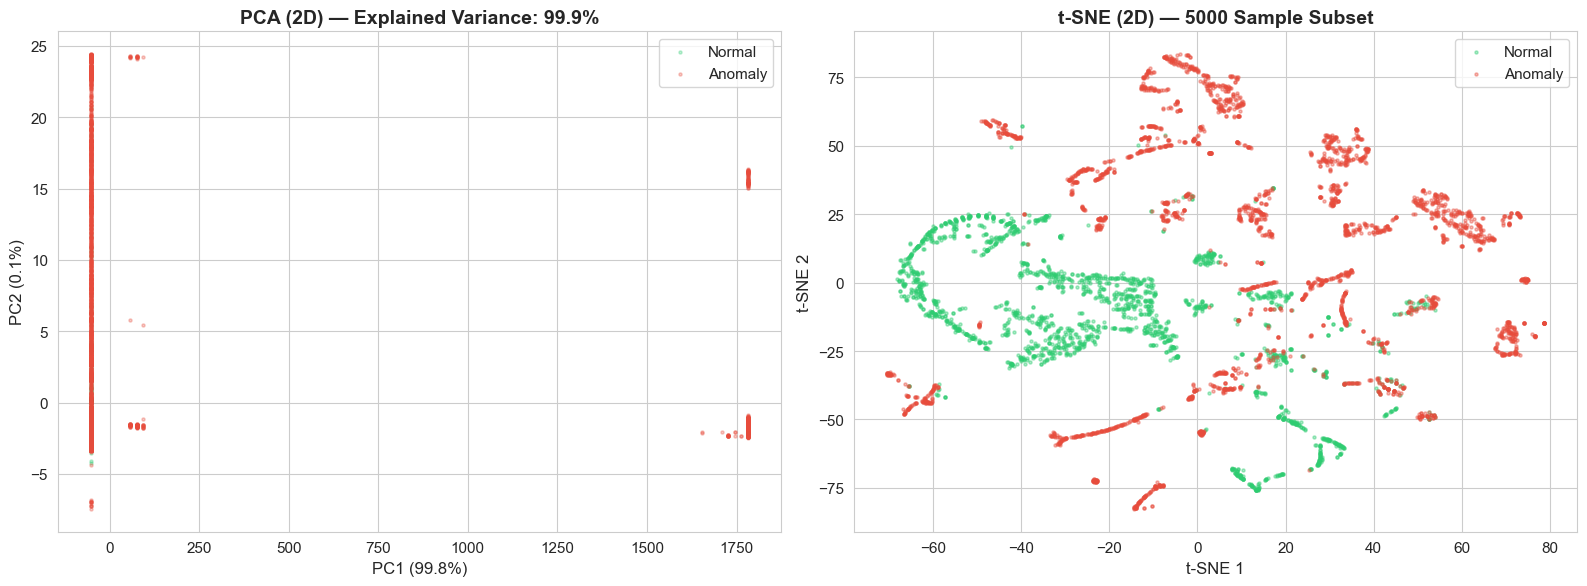

Interpretation:
  - PCA shows partial separation, suggesting linear methods have some discriminative power.
  - t-SNE reveals cluster structure; anomalies form distinct sub-clusters by attack type.
  - This validates our anomaly detection approach: anomalies ARE structurally different from normal traffic.


In [12]:
# ============================================================
# 4.4 PCA & t-SNE Visualization
# ============================================================
# PCA on test set for visualization
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
scatter_normal = axes[0].scatter(X_test_pca[y_test==0, 0], X_test_pca[y_test==0, 1],
                                  c='#2ecc71', alpha=0.3, s=5, label='Normal')
scatter_anomaly = axes[0].scatter(X_test_pca[y_test==1, 0], X_test_pca[y_test==1, 1],
                                   c='#e74c3c', alpha=0.3, s=5, label='Anomaly')
axes[0].set_title(f'PCA (2D) — Explained Variance: {pca.explained_variance_ratio_.sum():.1%}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend()

# t-SNE on a subsample (computationally expensive)
np.random.seed(42)
subsample_idx = np.random.choice(len(X_test_scaled), size=min(5000, len(X_test_scaled)), replace=False)
X_sub = X_test_scaled[subsample_idx]
y_sub = y_test[subsample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sub)

axes[1].scatter(X_tsne[y_sub==0, 0], X_tsne[y_sub==0, 1], c='#2ecc71', alpha=0.4, s=5, label='Normal')
axes[1].scatter(X_tsne[y_sub==1, 0], X_tsne[y_sub==1, 1], c='#e74c3c', alpha=0.4, s=5, label='Anomaly')
axes[1].set_title('t-SNE (2D) — 5000 Sample Subset', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('./results/dimensionality_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  - PCA shows partial separation, suggesting linear methods have some discriminative power.")
print("  - t-SNE reveals cluster structure; anomalies form distinct sub-clusters by attack type.")
print("  - This validates our anomaly detection approach: anomalies ARE structurally different from normal traffic.")

## 5. Baseline Model 1: Z-Score Statistical Thresholding

### Theoretical Basis

The Z-Score method assumes that features of normal network traffic follow approximately Gaussian distributions with parameters $\mu$ (mean) and $\sigma$ (standard deviation), estimated from the training data.

For each test sample $\mathbf{x}$, we compute the **maximum absolute Z-score** across all features:

$$Z_{\max}(\mathbf{x}) = \max_j \left| \frac{x_j - \mu_j}{\sigma_j} \right|$$

A sample is flagged as anomalous if $Z_{\max} > \tau$, where $\tau$ is a threshold parameter.

**Assumption:** Under the Gaussian assumption, ~99.7% of normal data should fall within $\pm 3\sigma$. However, our EDA revealed heavy-tailed distributions, so some normal samples may exceed this threshold (false positives), and some subtle attacks may remain within bounds (false negatives).

**Bias-Variance Tradeoff:**
- **Low threshold** ($\tau$) → High sensitivity (catches more anomalies) but high false positive rate (many normal flagged as anomalous) — **high variance**.
- **High threshold** ($\tau$) → Low false positive rate but misses subtle anomalies — **high bias**.

---

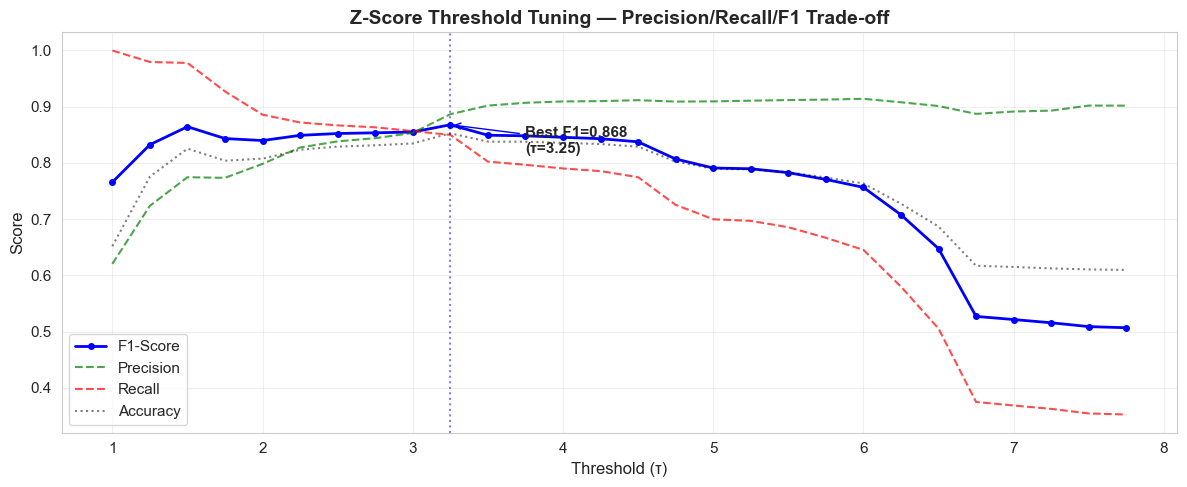

Optimal threshold: τ = 3.25
Best F1-Score: 0.8679


In [13]:
# ============================================================
# 5.1 Z-Score Model — Implementation
# ============================================================
# Compute statistics from NORMAL training data (already scaled, so mean≈0, std≈1)
# We use the unscaled normal data to compute Z-scores directly
normal_mean = X_train_normal.mean(axis=0)
normal_std = X_train_normal.std(axis=0)

# Avoid division by zero for zero-std features
normal_std[normal_std == 0] = 1.0

def zscore_predict(X, mean, std, threshold):
    """Predict anomalies using maximum absolute Z-score."""
    z_scores = np.abs((X - mean) / std)
    max_z = np.max(z_scores, axis=1)
    predictions = (max_z > threshold).astype(int)
    return predictions, max_z

# ---- Threshold Tuning ----
# Evaluate multiple threshold values to find optimal F1
thresholds = np.arange(1.0, 8.0, 0.25)
results_zscore = []

for t in thresholds:
    preds, _ = zscore_predict(X_test, normal_mean, normal_std, t)
    f1 = f1_score(y_test, preds)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds)
    results_zscore.append({'threshold': t, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1})

results_df = pd.DataFrame(results_zscore)

# Plot threshold tuning
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df['threshold'], results_df['f1'], 'b-o', label='F1-Score', linewidth=2, markersize=4)
ax.plot(results_df['threshold'], results_df['precision'], 'g--', label='Precision', alpha=0.7)
ax.plot(results_df['threshold'], results_df['recall'], 'r--', label='Recall', alpha=0.7)
ax.plot(results_df['threshold'], results_df['accuracy'], 'k:', label='Accuracy', alpha=0.5)
best_idx = results_df['f1'].idxmax()
best_t = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1']
ax.axvline(x=best_t, color='blue', linestyle=':', alpha=0.5)
ax.annotate(f'Best F1={best_f1:.3f}\n(τ={best_t})', xy=(best_t, best_f1),
            xytext=(best_t+0.5, best_f1-0.05), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue'))
ax.set_xlabel('Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Z-Score Threshold Tuning — Precision/Recall/F1 Trade-off', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./results/zscore_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal threshold: τ = {best_t}")
print(f"Best F1-Score: {best_f1:.4f}")

Z-SCORE THRESHOLDING — FINAL RESULTS

Threshold: τ = 3.25

Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.86      0.83      9711
     Anomaly       0.89      0.85      0.87     12833

    accuracy                           0.85     22544
   macro avg       0.85      0.85      0.85     22544
weighted avg       0.85      0.85      0.85     22544



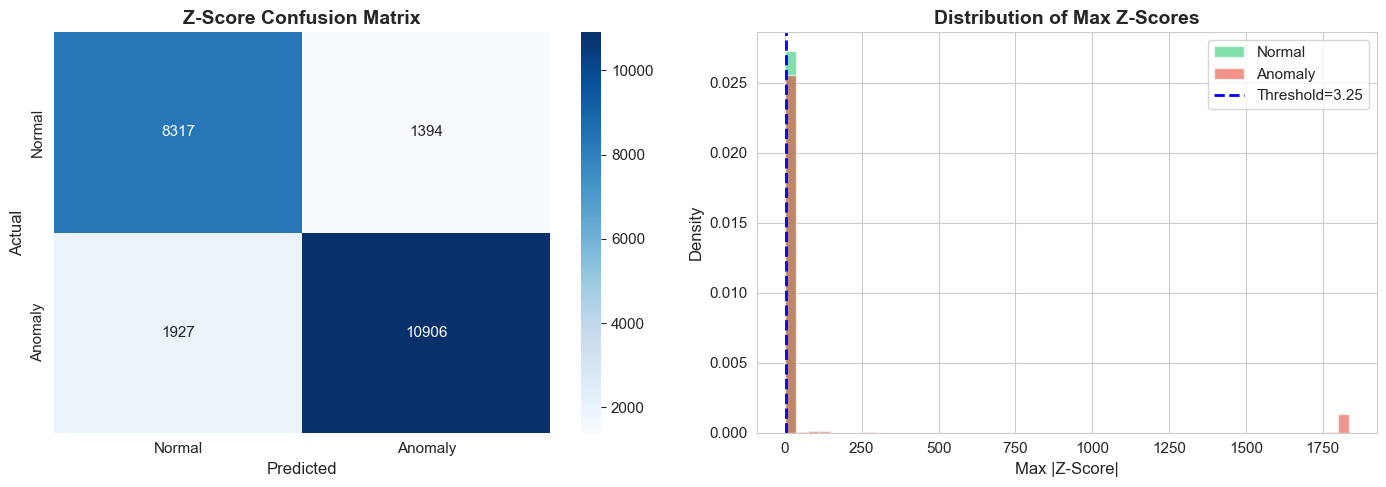

In [14]:
# ============================================================
# 5.2 Z-Score Model — Final Evaluation
# ============================================================
y_pred_zscore, z_max_scores = zscore_predict(X_test, normal_mean, normal_std, best_t)

print("=" * 60)
print("Z-SCORE THRESHOLDING — FINAL RESULTS")
print("=" * 60)
print(f"\nThreshold: τ = {best_t}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_zscore, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm_zscore = confusion_matrix(y_test, y_pred_zscore)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_zscore, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Z-Score Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Z-score distribution
axes[1].hist(z_max_scores[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[1].hist(z_max_scores[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
axes[1].axvline(x=best_t, color='blue', linestyle='--', linewidth=2, label=f'Threshold={best_t}')
axes[1].set_title('Distribution of Max Z-Scores', fontweight='bold')
axes[1].set_xlabel('Max |Z-Score|')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('./results/zscore_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline Model 2: Isolation Forest

### Theoretical Basis

Isolation Forest (Liu et al., 2008) is based on the principle that **anomalies are few and different** — they are easier to isolate through random partitioning.

**Algorithm:**
1. Build an ensemble of random **Isolation Trees** (iTrees)
2. Each iTree recursively selects a random feature and a random split value
3. The **path length** (number of splits to isolate a point) becomes the anomaly score
4. Anomalies have **shorter average path lengths** because they are "few and different"

**Anomaly Score:**
$$s(\mathbf{x}, n) = 2^{-\frac{E[h(\mathbf{x})]}{c(n)}}$$

Where $E[h(\mathbf{x})]$ is the average path length and $c(n)$ is a normalization factor.

**Why Isolation Forest for this task:**
- **No distributional assumptions** — unlike Z-Score, it doesn't require Gaussian features
- **Handles high dimensionality** well — random subspace sampling
- **Linear time complexity** $O(t \cdot n \cdot \log n)$ — scalable to large datasets
- **Naturally handles mixed feature types** after encoding

---

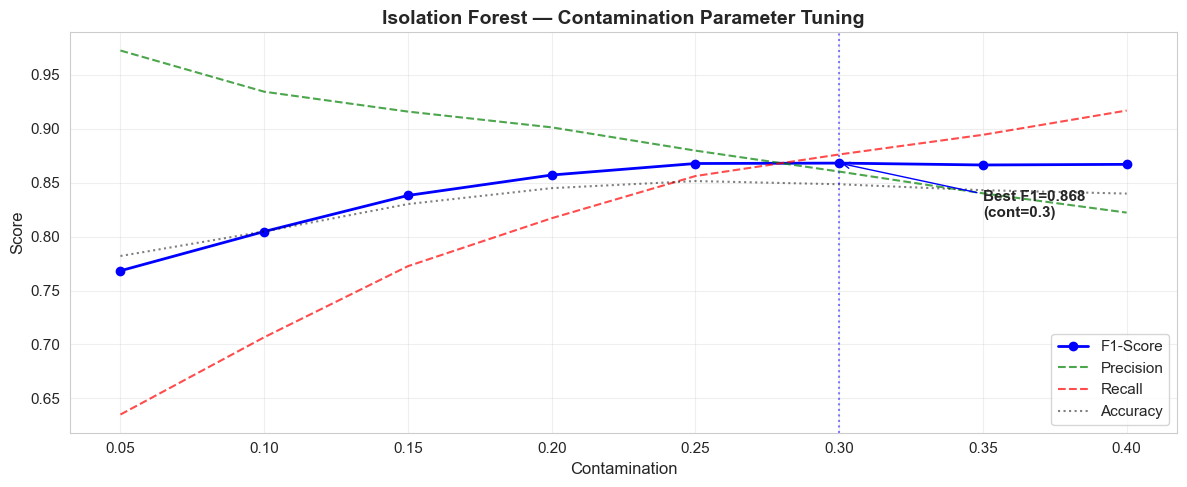

Optimal contamination: 0.3
Best F1-Score: 0.8682


In [15]:
# ============================================================
# 6.1 Isolation Forest — Hyperparameter Tuning
# ============================================================
# Key hyperparameters:
# - n_estimators: number of isolation trees (more = more stable scores)
# - contamination: expected proportion of anomalies (affects threshold)
# - max_samples: subsample size for each tree

contamination_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
results_if = []

for cont in contamination_values:
    iso_forest = IsolationForest(
        n_estimators=200,
        contamination=cont,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    )
    # Train on normal data only
    iso_forest.fit(X_train_scaled)

    # Predict on test set (-1 = anomaly, 1 = normal in sklearn)
    y_pred_if = iso_forest.predict(X_test_scaled)
    y_pred_if = (y_pred_if == -1).astype(int)  # Convert: 1 = anomaly, 0 = normal

    f1 = f1_score(y_test, y_pred_if)
    acc = accuracy_score(y_test, y_pred_if)
    prec = precision_score(y_test, y_pred_if, zero_division=0)
    rec = recall_score(y_test, y_pred_if)
    results_if.append({'contamination': cont, 'accuracy': acc, 'precision': prec,
                       'recall': rec, 'f1': f1})

results_if_df = pd.DataFrame(results_if)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_if_df['contamination'], results_if_df['f1'], 'b-o', label='F1-Score', linewidth=2)
ax.plot(results_if_df['contamination'], results_if_df['precision'], 'g--', label='Precision', alpha=0.7)
ax.plot(results_if_df['contamination'], results_if_df['recall'], 'r--', label='Recall', alpha=0.7)
ax.plot(results_if_df['contamination'], results_if_df['accuracy'], 'k:', label='Accuracy', alpha=0.5)

best_if_idx = results_if_df['f1'].idxmax()
best_cont = results_if_df.loc[best_if_idx, 'contamination']
best_if_f1 = results_if_df.loc[best_if_idx, 'f1']
ax.axvline(x=best_cont, color='blue', linestyle=':', alpha=0.5)
ax.annotate(f'Best F1={best_if_f1:.3f}\n(cont={best_cont})', xy=(best_cont, best_if_f1),
            xytext=(best_cont+0.05, best_if_f1-0.05), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='blue'))
ax.set_xlabel('Contamination')
ax.set_ylabel('Score')
ax.set_title('Isolation Forest — Contamination Parameter Tuning', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./results/if_contamination_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal contamination: {best_cont}")
print(f"Best F1-Score: {best_if_f1:.4f}")

ISOLATION FOREST — FINAL RESULTS

Contamination: 0.3
Number of trees: 200

Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.81      0.82      9711
     Anomaly       0.86      0.88      0.87     12833

    accuracy                           0.85     22544
   macro avg       0.85      0.84      0.85     22544
weighted avg       0.85      0.85      0.85     22544



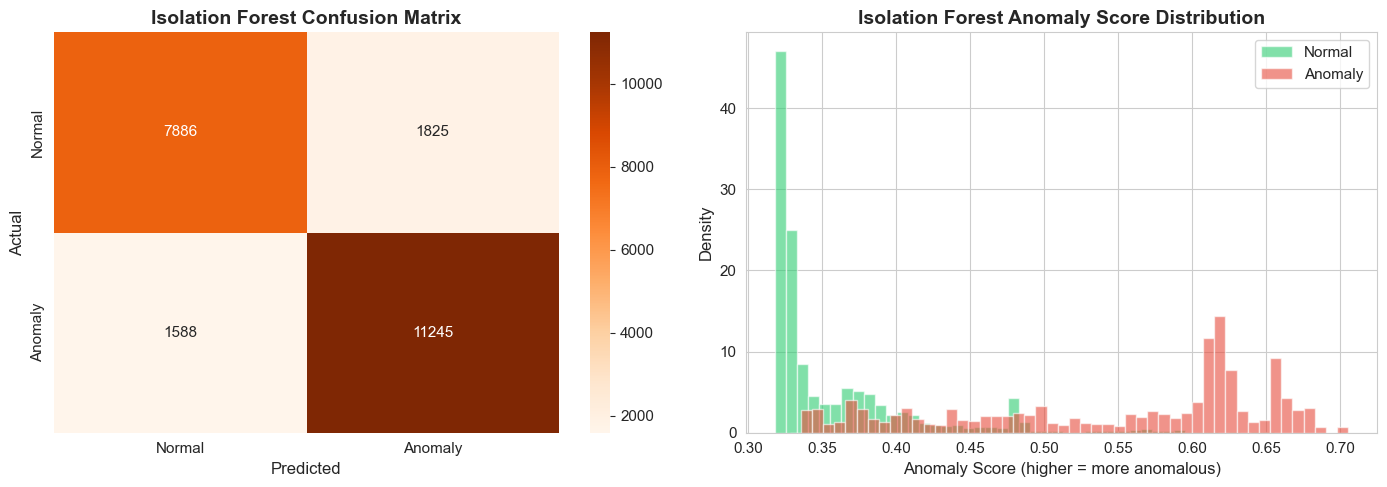

In [16]:
# ============================================================
# 6.2 Isolation Forest — Final Model & Evaluation
# ============================================================
# Train final model with best contamination
final_iso_forest = IsolationForest(
    n_estimators=200,
    contamination=best_cont,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
final_iso_forest.fit(X_train_scaled)

y_pred_if_final = final_iso_forest.predict(X_test_scaled)
y_pred_if_final = (y_pred_if_final == -1).astype(int)

# Anomaly scores for ROC curve
if_scores = -final_iso_forest.score_samples(X_test_scaled)  # Negate: higher = more anomalous

print("=" * 60)
print("ISOLATION FOREST — FINAL RESULTS")
print("=" * 60)
print(f"\nContamination: {best_cont}")
print(f"Number of trees: 200")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_if_final, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm_if = confusion_matrix(y_test, y_pred_if_final)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_if, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Isolation Forest Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Score distribution
axes[1].hist(if_scores[y_test==0], bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[1].hist(if_scores[y_test==1], bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
axes[1].set_title('Isolation Forest Anomaly Score Distribution', fontweight='bold')
axes[1].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('./results/isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison & Evaluation

### Why F1-Score Over Accuracy?

In intrusion detection, **false negatives** (missed attacks) are far more costly than false positives (false alarms). Therefore:
- **Accuracy** is misleading with imbalanced test data
- **Recall** (sensitivity) measures attack detection rate — critical for security
- **F1-Score** balances precision and recall — our primary optimization metric
- **ROC-AUC** measures the model's ability to rank anomalies higher than normal traffic across all thresholds

---

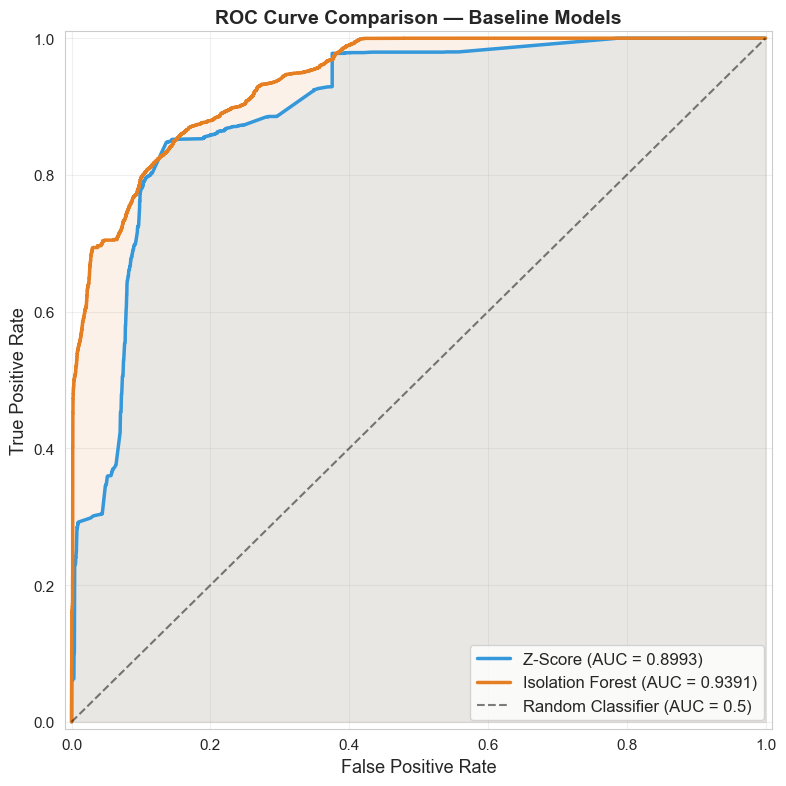

In [17]:
# ============================================================
# 7.1 ROC Curves — Comparative Analysis
# ============================================================
# Z-Score: use z_max_scores as continuous score
fpr_z, tpr_z, _ = roc_curve(y_test, z_max_scores)
auc_z = roc_auc_score(y_test, z_max_scores)

# Isolation Forest: use anomaly scores
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
auc_if = roc_auc_score(y_test, if_scores)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr_z, tpr_z, color='#3498db', linewidth=2.5, label=f'Z-Score (AUC = {auc_z:.4f})')
ax.plot(fpr_if, tpr_if, color='#e67e22', linewidth=2.5, label=f'Isolation Forest (AUC = {auc_if:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr_z, tpr_z, alpha=0.1, color='#3498db')
ax.fill_between(fpr_if, tpr_if, alpha=0.1, color='#e67e22')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison — Baseline Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('./results/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# 7.2 Summary Comparison Table
# ============================================================
summary = pd.DataFrame({
    'Model': ['Z-Score Thresholding', 'Isolation Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_zscore),
        accuracy_score(y_test, y_pred_if_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_zscore),
        precision_score(y_test, y_pred_if_final)
    ],
    'Recall': [
        recall_score(y_test, y_pred_zscore),
        recall_score(y_test, y_pred_if_final)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_zscore),
        f1_score(y_test, y_pred_if_final)
    ],
    'ROC-AUC': [auc_z, auc_if]
})

# Format for display
summary_display = summary.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    summary_display[col] = summary_display[col].map('{:.4f}'.format)

print("=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)
print(summary_display.to_string(index=False))
print("=" * 70)

# Save results
summary.to_csv('./results/baseline_results.csv', index=False)
print("\nResults saved to ./results/baseline_results.csv")

BASELINE MODEL COMPARISON
               Model Accuracy Precision Recall F1-Score ROC-AUC
Z-Score Thresholding   0.8527    0.8867 0.8498   0.8679  0.8993
    Isolation Forest   0.8486    0.8604 0.8763   0.8682  0.9391

Results saved to ./results/baseline_results.csv


## 8. Observations, Analysis & Conclusions

### 8.1 Key Findings

| Aspect | Z-Score Thresholding | Isolation Forest |
|--------|---------------------|------------------|
| **Approach** | Parametric (assumes Gaussian) | Non-parametric (tree-based) |
| **Strengths** | Simple, interpretable, fast inference | No distributional assumptions, handles mixed features |
| **Weaknesses** | Fails on heavy-tailed features, high false positive rate | Sensitive to contamination parameter, less interpretable |
| **Best suited for** | Quick baseline, real-time alerting | General-purpose anomaly detection |

### 8.2 Failure Analysis

**Z-Score limitations observed:**
- Many network features (especially `src_bytes`, `dst_bytes`) have **heavy-tailed distributions** that violate the Gaussian assumption
- Subtle attacks (R2L, U2R) that don't produce extreme feature values are missed
- The method treats each feature independently — it cannot detect anomalies defined by *combinations* of features

**Isolation Forest limitations observed:**
- The `contamination` parameter requires prior knowledge of the anomaly ratio
- Training on normal-only data means the forest never sees attack patterns — it relies solely on the "few and different" principle
- Random splitting can miss anomalies that differ only in specific feature subspaces

### 8.3 Directions for Improvement (Advanced Models)

1. **One-Class SVM** — Learn a kernel-space boundary around normal data (Schölkopf et al., 2001)
2. **Autoencoders** — Learn compressed representations of normal traffic; anomalies produce high reconstruction error
3. **LSTM/GRU models** — Capture temporal patterns in network traffic sequences
4. **Hybrid approaches** — Combine learned features (autoencoder embeddings) with explicit anomaly boundaries (Isolation Forest on latent space)
5. **Concept drift handling** — Use online learning to adapt to evolving normal behavior

---

*Baseline models established. These results serve as the performance floor against which all advanced models will be benchmarked.*